# PCA Score all Data

Apply the trained PCA model (NB 11) to **all three splits** (train / val / test_intern)
and visualise anomaly predictions across the full timeline.

**Preconditions**
- `run_preprocessing()` has been run → `data/processed/` contains the `.npy` arrays
- NB 11 has been run → `models/pca_bootcamp.pkl` exists

**Outputs**
- Score timeline plot across all data
- Per-split metrics table
- Full prediction array `y_pred_all` (concatenated, same row order as original data)

## 0 - Setup & Imports

In [19]:
import sys, json, pickle, time
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sentinel.ml_logic.scorer    import score_windows
from sentinel.ml_logic.metrics    import event_f05, corrected_event_f05, row_precision_recall
from sentinel.params import WINDOW_SIZE, ANOMALY_COLOR, NOMINAL_COLOR

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')

# Threshold from NB 11 threshold sweep
THRESHOLD = 0.060404

## 1 - Load Model & Data

In [20]:
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)
WIN = cfg['window_size']

with open(MODELS_DIR / 'pca.pkl', 'rb') as f:
    pca = pickle.load(f)
print(f'PCA loaded: {pca.n_components_} components')

print('Loading arrays ...')
t0 = time.time()
train_scaled = np.load(PROCESSED_DIR / 'train_scaled.npy')
val_scaled   = np.load(PROCESSED_DIR / 'val_scaled.npy')
test_scaled  = np.load(PROCESSED_DIR / 'test_intern_scaled.npy')
y_train      = np.load(PROCESSED_DIR / 'y_train.npy')
y_val        = np.load(PROCESSED_DIR / 'y_val.npy')
y_test       = np.load(PROCESSED_DIR / 'y_test_intern.npy')
print(f'Loaded in {time.time()-t0:.1f}s')
print(f'train : {train_scaled.shape}  ({int(y_train.sum()):>7,} anom rows)')
print(f'val   : {val_scaled.shape}  ({int(y_val.sum()):>7,} anom rows)')
print(f'test  : {test_scaled.shape}  ({int(y_test.sum()):>7,} anom rows)')

PCA loaded: 38 components
Loading arrays ...
Loaded in 2.1s
train : (10309824, 58)  (1,082,680 anom rows)
val   : (2232277, 58)  (246,463 anom rows)
test  : (2186220, 58)  (214,961 anom rows)


## 2 - Score All Splits

In [21]:
t0 = time.time()
train_scores = score_windows(pca, train_scaled, win=WIN)
print(f'train scored in {time.time()-t0:.1f}s  range [{train_scores.min():.4f}, {train_scores.max():.4f}]')

t0 = time.time()
val_scores = score_windows(pca, val_scaled, win=WIN)
print(f'val   scored in {time.time()-t0:.1f}s  range [{val_scores.min():.4f}, {val_scores.max():.4f}]')

t0 = time.time()
test_scores = score_windows(pca, test_scaled, win=WIN)
print(f'test  scored in {time.time()-t0:.1f}s  range [{test_scores.min():.4f}, {test_scores.max():.4f}]')

all_scores = np.concatenate([train_scores, val_scores, test_scores])
y_all      = np.concatenate([y_train,      y_val,      y_test])
y_pred_all = (all_scores > THRESHOLD).astype(np.int8)

print(f'\nTotal rows : {len(all_scores):,}')
print(f'Flagged    : {y_pred_all.sum():,}  ({y_pred_all.mean()*100:.2f}%)')

train scored in 10.5s  range [0.0107, 8243515.0000]
val   scored in 1.3s  range [0.0175, 664.9958]
test  scored in 1.2s  range [0.0258, 3.0895]

Total rows : 14,728,321
Flagged    : 1,573,620  (10.68%)


In [22]:
test_scores

array([0.02984171, 0.02984171, 0.02984171, ..., 0.2162947 , 0.2162947 ,
       0.2162947 ], dtype=float32)

## 3 - Score Timeline

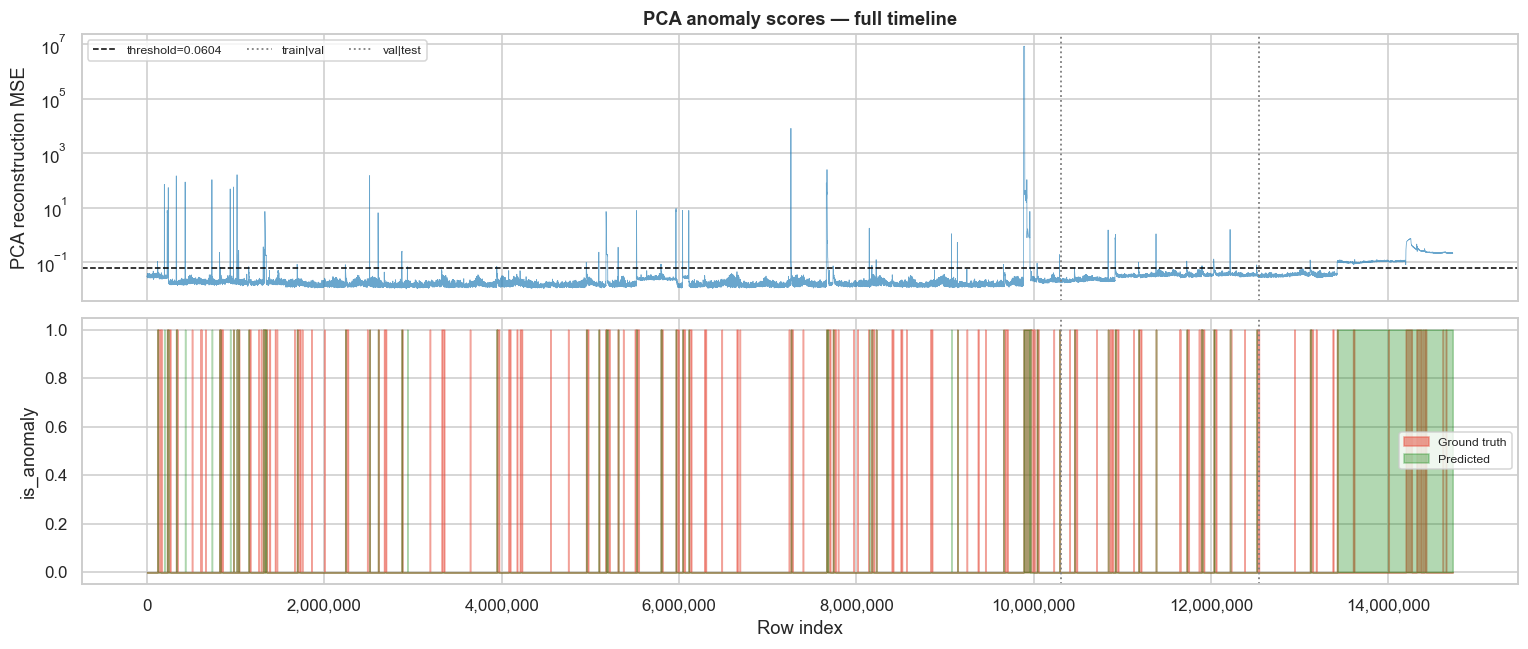

In [23]:
# Downsample for plot readability
STEP = 500
idx  = np.arange(0, len(all_scores), STEP)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Score curve
ax1.plot(idx, all_scores[idx], lw=0.5, color=NOMINAL_COLOR, alpha=0.7)
ax1.axhline(THRESHOLD, color='black', ls='--', lw=1, label=f'threshold={THRESHOLD:.4f}')

# Mark split boundaries
n_train = len(train_scores)
n_val   = len(val_scores)

for xv, lbl in [(n_train, 'train|val'), (n_train+n_val, 'val|test')]:
    ax1.axvline(xv, color='grey', ls=':', lw=1.2, label=lbl)
ax1.set_ylabel('PCA reconstruction MSE')
ax1.set_title('PCA anomaly scores — full timeline', fontweight='bold')
ax1.set_yscale('log')
ax1.legend(fontsize=8, ncol=3)

import matplotlib.ticker as mticker
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))


# Ground truth vs predictions
ax2.fill_between(idx, y_all[idx],      alpha=0.5, color=ANOMALY_COLOR, label='Ground truth')
ax2.fill_between(idx, y_pred_all[idx], alpha=0.3, color='green',       label='Predicted')
ax2.axvline(n_train,       color='grey', ls=':', lw=1.2)
ax2.axvline(n_train+n_val, color='grey', ls=':', lw=1.2)
ax2.set_ylabel('is_anomaly')
ax2.set_xlabel('Row index')
ax2.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 4 - Per-Split Metrics

In [24]:
rows = []
for name, scores, y_true in [
    ('train',     train_scores, y_train),
    ('val',       val_scores,   y_val),
    ('test_intern', test_scores, y_test),
]:
    y_pred = (scores > THRESHOLD).astype(np.int8)
    ev  = event_f05(y_true, y_pred)
    esa = corrected_event_f05(y_true, y_pred)
    rw  = row_precision_recall(y_true, y_pred)
    rows.append({
        'Split'             : name,
        'Event F0.5'        : round(ev['f_score'],  4),
        'Event recall'      : round(ev['recall'],   4),
        'Event precision'   : round(ev['precision'],4),
        'ESA corr. F0.5'    : round(esa['f_score'], 4),
        'Row F1'            : round(rw['f1'],        4),
        'Flagged rows'      : int(y_pred.sum()),
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

      Split  Event F0.5  Event recall  Event precision  ESA corr. F0.5  Row F1  Flagged rows
      train      0.8463        0.5547           0.9744          0.8460  0.3416        229300
        val      0.8333        0.5000           1.0000          0.8332  0.2181         30600
test_intern      0.9843        0.9259           1.0000          0.4736  0.2281       1313720
